In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model and scaler
model = joblib.load('../models/best_model.pkl')
scaler = joblib.load('../models/scaler.pkl')

print("✅ Model and scaler loaded!")

✅ Model and scaler loaded!


In [2]:
# Load feature names
df = pd.read_csv('../data/cleaned_data.csv')
feature_names = df.drop('Churn', axis=1).columns.tolist()
print("Features needed:")
for f in feature_names:
    print(f"  - {f}")

Features needed:
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - tenure
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - MonthlyCharges
  - TotalCharges


In [3]:
# PREDICT FOR SAMPLE CUSTOMERS
def predict_churn(customer_data):
    """Predict churn for a customer"""
    df_customer = pd.DataFrame([customer_data])
    df_scaled = scaler.transform(df_customer)
    probability = model.predict_proba(df_scaled)[0][1]
    prediction = model.predict(df_scaled)[0]
    return probability, prediction

def show_prediction(customer_data, customer_name):
    """Show prediction with retention strategy"""
    probability, prediction = predict_churn(customer_data)
    
    print("=" * 55)
    print(f"🧑 Customer: {customer_name}")
    print("=" * 55)
    print(f"  Churn Probability : {probability:.1%}")
    print(f"  Prediction        : {'Will Churn 🚨' if prediction == 1 else 'Will Stay ✅'}")
    
    if probability > 0.7:
        print("\n  🚨 HIGH RISK CUSTOMER")
        print("  Retention Strategies:")
        print("  ✓ Call within 24 hours")
        print("  ✓ Offer 30% discount for 3 months")
        print("  ✓ Free upgrade to premium plan")
        print("  ✓ Assign dedicated account manager")
    elif probability > 0.4:
        print("\n  ⚠️  MEDIUM RISK CUSTOMER")
        print("  Retention Strategies:")
        print("  ✓ Send personalized email offer")
        print("  ✓ Offer 15% loyalty discount")
        print("  ✓ Free add-on for 1 month")
    else:
        print("\n  ✅ LOW RISK CUSTOMER")
        print("  Retention Strategies:")
        print("  ✓ Include in loyalty program")
        print("  ✓ Regular newsletter")
        print("  ✓ Ask for referrals")
    print()

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [4]:
# Test with 3 different customers

# Customer 1: High Risk (Month-to-month, Fiber, short tenure)
customer_1 = {
    'gender': 1, 'SeniorCitizen': 0, 'Partner': 0, 'Dependents': 0,
    'tenure': 3, 'PhoneService': 1, 'MultipleLines': 0,
    'InternetService': 1, 'OnlineSecurity': 0, 'OnlineBackup': 0,
    'DeviceProtection': 0, 'TechSupport': 0, 'StreamingTV': 1,
    'StreamingMovies': 1, 'Contract': 0, 'PaperlessBilling': 1,
    'PaymentMethod': 2, 'MonthlyCharges': 85.5, 'TotalCharges': 256.5
}

# Customer 2: Medium Risk
customer_2 = {
    'gender': 0, 'SeniorCitizen': 0, 'Partner': 1, 'Dependents': 0,
    'tenure': 15, 'PhoneService': 1, 'MultipleLines': 1,
    'InternetService': 0, 'OnlineSecurity': 0, 'OnlineBackup': 1,
    'DeviceProtection': 0, 'TechSupport': 0, 'StreamingTV': 0,
    'StreamingMovies': 0, 'Contract': 0, 'PaperlessBilling': 0,
    'PaymentMethod': 1, 'MonthlyCharges': 55.0, 'TotalCharges': 825.0
}

# Customer 3: Low Risk (Long tenure, 2-year contract)
customer_3 = {
    'gender': 1, 'SeniorCitizen': 0, 'Partner': 1, 'Dependents': 1,
    'tenure': 60, 'PhoneService': 1, 'MultipleLines': 1,
    'InternetService': 0, 'OnlineSecurity': 1, 'OnlineBackup': 1,
    'DeviceProtection': 1, 'TechSupport': 1, 'StreamingTV': 0,
    'StreamingMovies': 0, 'Contract': 2, 'PaperlessBilling': 0,
    'PaymentMethod': 0, 'MonthlyCharges': 45.0, 'TotalCharges': 2700.0
}

show_prediction(customer_1, "John Doe (New Fiber Customer)")
show_prediction(customer_2, "Jane Smith (DSL, 1 year)")
show_prediction(customer_3, "Bob Wilson (Long-term, 2-year contract)")

🧑 Customer: John Doe (New Fiber Customer)
  Churn Probability : 71.2%
  Prediction        : Will Churn 🚨

  🚨 HIGH RISK CUSTOMER
  Retention Strategies:
  ✓ Call within 24 hours
  ✓ Offer 30% discount for 3 months
  ✓ Free upgrade to premium plan
  ✓ Assign dedicated account manager

🧑 Customer: Jane Smith (DSL, 1 year)
  Churn Probability : 23.8%
  Prediction        : Will Stay ✅

  ✅ LOW RISK CUSTOMER
  Retention Strategies:
  ✓ Include in loyalty program
  ✓ Regular newsletter
  ✓ Ask for referrals

🧑 Customer: Bob Wilson (Long-term, 2-year contract)
  Churn Probability : 0.9%
  Prediction        : Will Stay ✅

  ✅ LOW RISK CUSTOMER
  Retention Strategies:
  ✓ Include in loyalty program
  ✓ Regular newsletter
  ✓ Ask for referrals



In [5]:
# Batch Prediction on Test Data
df_full = pd.read_csv('../data/cleaned_data.csv')

X_all = df_full.drop('Churn', axis=1)
X_all_scaled = scaler.transform(X_all)

probabilities = model.predict_proba(X_all_scaled)[:, 1]
predictions = model.predict(X_all_scaled)

df_full['Churn_Probability'] = probabilities
df_full['Churn_Prediction'] = predictions
df_full['Risk_Level'] = pd.cut(
    probabilities,
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk Level Distribution:")
print(df_full['Risk_Level'].value_counts())
print(f"\nTotal High Risk Customers  : {(df_full['Risk_Level'] == 'High Risk').sum()}")
print(f"Total Medium Risk Customers: {(df_full['Risk_Level'] == 'Medium Risk').sum()}")
print(f"Total Low Risk Customers   : {(df_full['Risk_Level'] == 'Low Risk').sum()}")

df_full[['Churn_Probability', 'Risk_Level']].head(10)

Risk Level Distribution:
Risk_Level
Low Risk       4991
Medium Risk    1379
High Risk       673
Name: count, dtype: int64

Total High Risk Customers  : 673
Total Medium Risk Customers: 1379
Total Low Risk Customers   : 4991


,Churn_Probability,Risk_Level
0,0.640499,Medium Risk
1,0.020379,Low Risk
2,0.461905,Medium Risk
3,0.022145,Low Risk
4,0.636165,Medium Risk
5,0.921217,High Risk
6,0.463268,Medium Risk
7,0.154822,Low Risk
8,0.667696,Medium Risk
9,0.019369,Low Risk


In [6]:
# Save predictions to CSV
df_full.to_csv('../data/predictions.csv', index=False)

print("✅ Predictions saved to ../data/predictions.csv")
print(f"\nFile contains:")
print(f"  - All original features")
print(f"  - Churn_Probability column")
print(f"  - Churn_Prediction column")
print(f"  - Risk_Level column")
print(f"\nTotal rows saved: {len(df_full)}")

✅ Predictions saved to ../data/predictions.csv

File contains:
  - All original features
  - Churn_Probability column
  - Churn_Prediction column
  - Risk_Level column

Total rows saved: 7043


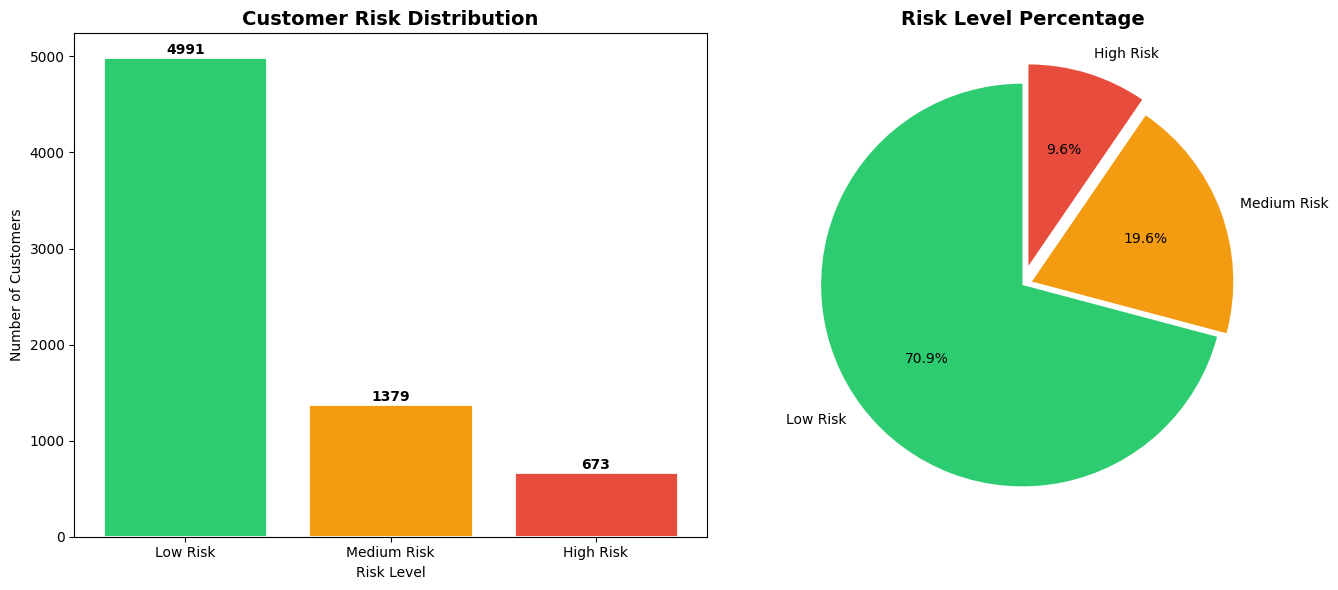

✅ Plot saved!


In [7]:
# PLOT: Risk Level Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count by risk level
risk_counts = df_full['Risk_Level'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Bar chart
axes[0].bar(risk_counts.index, risk_counts.values,
            color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Customer Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Customers')
for i, val in enumerate(risk_counts.values):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values,
            labels=risk_counts.index,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05, 0.1))
axes[1].set_title('Risk Level Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../src/images/12_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

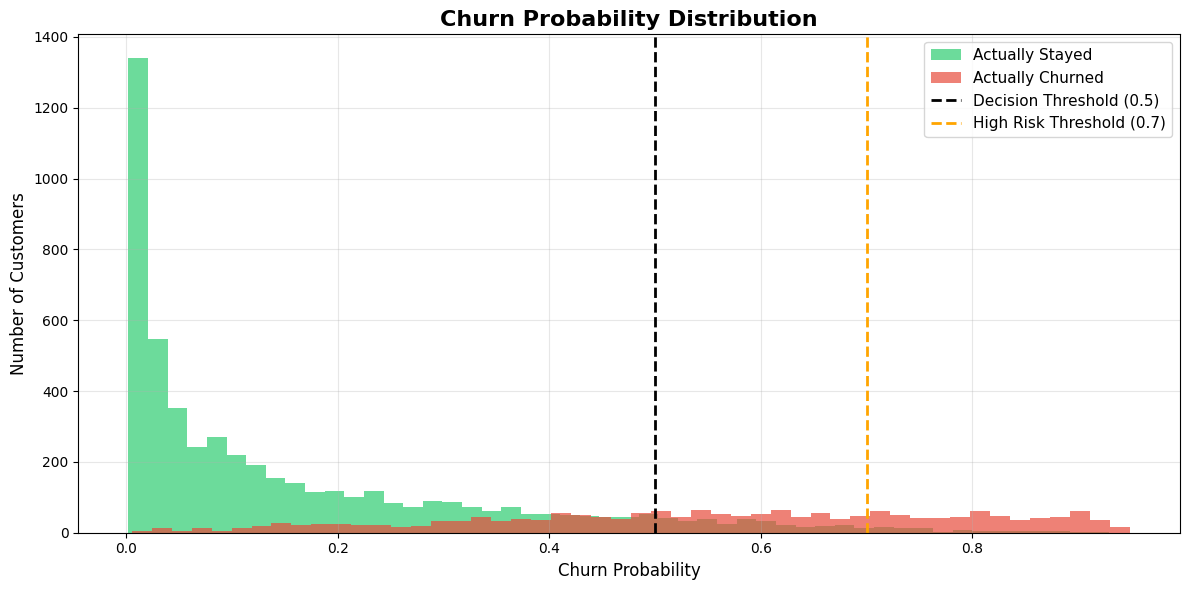

✅ Plot saved!


In [8]:
# PLOT: Churn Probability Distribution
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_full[df_full['Churn'] == 0]['Churn_Probability'],
        bins=50, alpha=0.7, color='#2ecc71', label='Actually Stayed')
ax.hist(df_full[df_full['Churn'] == 1]['Churn_Probability'],
        bins=50, alpha=0.7, color='#e74c3c', label='Actually Churned')

ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=2, label='Decision Threshold (0.5)')
ax.axvline(x=0.7, color='orange', linestyle='--',
           linewidth=2, label='High Risk Threshold (0.7)')

ax.set_title('Churn Probability Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../src/images/13_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [9]:
# Show TOP 10 highest risk customers
print("=" * 60)
print("🚨 TOP 10 HIGHEST RISK CUSTOMERS")
print("=" * 60)

top_risk = df_full.nlargest(10, 'Churn_Probability')[
    ['tenure', 'MonthlyCharges', 'Contract',
     'InternetService', 'Churn_Probability', 'Risk_Level']
]

top_risk['Churn_Probability'] = top_risk['Churn_Probability'].apply(
    lambda x: f"{x:.1%}"
)

print(top_risk.to_string(index=True))
print("\n⚠️  These customers need IMMEDIATE retention action!")

🚨 TOP 10 HIGHEST RISK CUSTOMERS
      tenure  MonthlyCharges  Contract  InternetService Churn_Probability Risk_Level
1976       1           93.55         0                1             94.9%  High Risk
4800       1           94.00         0                1             94.7%  High Risk
4517      11           99.55         0                1             94.5%  High Risk
2577       1           94.60         0                1             94.4%  High Risk
3209       1           93.85         0                1             94.4%  High Risk
6623       1           76.45         0                1             94.2%  High Risk
2464       1           77.15         0                1             94.0%  High Risk
6317       1           79.15         0                1             93.9%  High Risk
4585       1           85.05         0                1             93.9%  High Risk
7032       1           75.75         0                1             93.8%  High Risk

⚠️  These customers need IMMEDIA

In [10]:
# FINAL SUMMARY of Notebook 4
print("=" * 60)
print("✅ NOTEBOOK 4 COMPLETE!")
print("=" * 60)
print("\n📋 What we did:")
print("  ✓ Loaded trained model")
print("  ✓ Predicted on 3 sample customers")
print("  ✓ Ran batch predictions on all customers")
print("  ✓ Assigned risk levels")
print("  ✓ Saved predictions to CSV")
print("  ✓ Visualized risk distribution")
print("  ✓ Identified top 10 highest risk customers")
print("\n👉 Move to Notebook 5: Business Insights")

✅ NOTEBOOK 4 COMPLETE!

📋 What we did:
  ✓ Loaded trained model
  ✓ Predicted on 3 sample customers
  ✓ Ran batch predictions on all customers
  ✓ Assigned risk levels
  ✓ Saved predictions to CSV
  ✓ Visualized risk distribution
  ✓ Identified top 10 highest risk customers

👉 Move to Notebook 5: Business Insights
